# Does the "abandoned baby" call the turn? 👶
### A doji marooned by gaps on both sides — candlestick lore's rarest reversal — meets a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Island_doji_forecasts%3F: Busted](https://img.shields.io/badge/Island_doji_forecasts%3F-Busted-8b949e?style=flat-square)

Candlestick lore has a famously dramatic reversal: the **abandoned baby**. Picture a market falling, then a tiny indecisive candle — a **doji** (it opens and closes at almost the same price) — that **gaps down**, stranded below everything around it. The very next day price **gaps back up** and away, leaving that doji marooned on its own little price *island*. The lore (Steve Nison, who brought candlesticks West; Bulkowski, who ranks it among the most 'reliable') says this island doji **calls the bottom** — buy the up-gap, ride the reversal.

It *looks* spellbinding on a hand-picked chart. But it's also one of the **rarest** patterns, and rare patterns are exactly where a few lucky charts fool you. So we did the fair thing: encode the abandoned baby **mechanically** (a real doji, a real prior decline, real gaps on both sides — no eyeballing), fire it across five big indices over 21 years, and time the result against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from abandoned_baby import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real abandoned-baby cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 80, 'doji_frac': 0.1, 'sma_win': 20, 'full_gap': False, 'fp_spy': '4cb5244f3990', 'h5': (5, 80, 44.3, 56, 1.53, 10.3, 34.1, 42.3, 1.02, 0.312), 'h10': (10, 80, 88.4, 60, 2.29, 53.6, 34.9, 86.4, 0.71, 0.478), 'h20': (20, 80, 79.6, 57, 1.3, 33.1, 46.5, 77.6, 0.67, 0.501), 'h60': (60, 80, 407.2, 75, 3.54, 118.9, 288.3, 405.2, 2.58, 0.011), 'per': [('SPY', 15, 208.4, 1.84, 39.3, 169.1), ('QQQ', 13, -170.6, -1.24, 88.2, -258.8), ('IWM', 13, 74.3, 0.67, 2.7, 71.7), ('DIA', 17, 299.5, 2.19, 33.7, 265.8), ('GLD', 22, -27.3, -0.26, 1.5, -28.8)], 'placebo': (208.4, 0.307, 104), 'placebo60': [('SPY', 684.9, 0.07), ('QQQ', 38.1, 0.936), ('IWM', 302.8, 0.473), ('DIA', 780.5, 0.018), ('GLD', 209.3, 0.76)], 'syn': [(0.0, 48, -23.1, 56, -0.19), (0.6, 139, 404.4, 69, 5.96)]}


real abandoned-baby cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy the abandoned-baby confirmation, do I make money? | **A little — and a bit more than random at long horizons.** Unlike most chart tools, the pattern actually edges out random entries at every horizon. |
| Is it *statistically* convincing? | **Only at 60 days, and only barely.** The pattern-vs-random test clears the bar at 60 days (*t* = 2.58) but is noise at 5/10/20 days — and the whole thing rides just **80 trades**. |
| Is it *the island gaps* doing the work? | **No.** Scramble the island geometry (keep a doji-after-a-decline, drop the gaps) and the result barely changes. The *abandoned* part isn't load-bearing. |
| So is it a tradable edge? | **Not really.** One horizon, 80 trades, and the sign flips between instruments. Something flickers; nothing you could deploy. |

> The abandoned baby is a vivid way to *mark* a bottom after the fact. As a *forecast* it's a **faint, fragile flicker** — a whiff of signal at one horizon that the island geometry can't actually claim credit for.

## 1 · The claim

> *"A down-trend, then a **doji** that **gaps down** below the prior candle, then a candle that **gaps up** above the doji and closes higher. The doji is 'abandoned' — left on a price island by gaps on both sides. It marks the bottom: buy the confirmation candle."*

This is **Steve Nison's** abandoned baby (from the Japanese rice-trading tradition, popularised in *Japanese Candlestick Charting Techniques*, 1991) — the candlestick cousin of the Western **island reversal**. It's billed as one of the rarest *and* most reliable candlestick signals. So: does the island doji actually forecast the turn?

## 2 · So what?

If a three-bar shape genuinely *forecast* reversals, that would be a clean, tradable crack in market efficiency — three candles predicting a turn. That's the dream the pattern sells.

But two traps are built in. First, it's drawn on indices that drift **up** over time, so *any* dip-buying rule will look profitable — we have to compare against buying on **random days**, not against zero. Second, the pattern is **rare**: a handful of examples per instrument, which is exactly the regime where a couple of lucky bounces manufacture a 'reliable pattern'. To separate the **island** from the **tide** (and from **luck**) we encode it mechanically and race it honestly.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Define the doji mechanically.** A candle whose body (open-to-close) is **≤ 10%** of its high-low range — small and indecisive.
2. **Require a real decline.** The candle before the doji must be a down candle below its **20-day average** — the bullish abandoned baby needs something to reverse.
3. **Require gaps on both sides.** The doji gaps **down** away from that candle, and the confirmation candle gaps **up** away from the doji and closes higher — the *island*.
4. **Trade the lore.** Buy at the **next close** after the confirmation candle; measure the return over the next **5 / 10 / 20 / 60 days**.
5. **The honest baseline.** Do the exact same hold on **random days**. If the island forecasts, the pattern must beat random. *If it doesn't, it's a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical abandoned baby even look like? Here's SPY with the islands the rule would buy marked (the doji stranded by gaps on both sides).

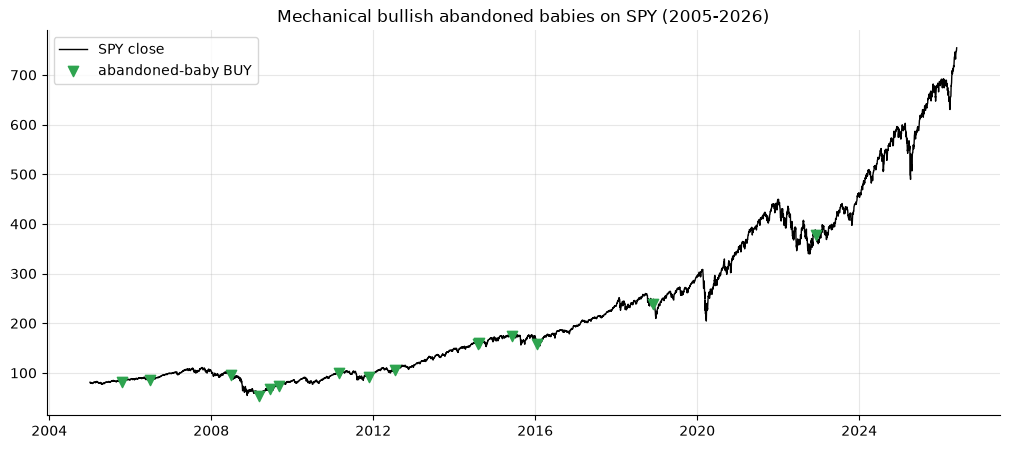

abandoned babies on SPY: 15


In [2]:
if HAVE_REAL:
    b = load('SPY'); cl = b['close']
    ent = st.abandoned_baby_entries(b, R['doji_frac'], R['sma_win'], R['full_gap'])
    fig, ax = plt.subplots(figsize=(10.2, 4.6))
    ax.plot(cl.index, cl.values, c='k', lw=1.0, label='SPY close')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=55, zorder=5, marker='v', label='abandoned-baby BUY')
    ax.set_title('Mechanical bullish abandoned babies on SPY (2005-2026)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('abandoned babies on SPY:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers; SPY had', R['per'][0][1], 'islands)')

They're rare — a dozen-and-change per instrument across 21 years. The question is whether those green buy marks are followed by bounces. **Let's race the abandoned baby against random entries** at four horizons. Blue = buy the island; grey = buy on random days.

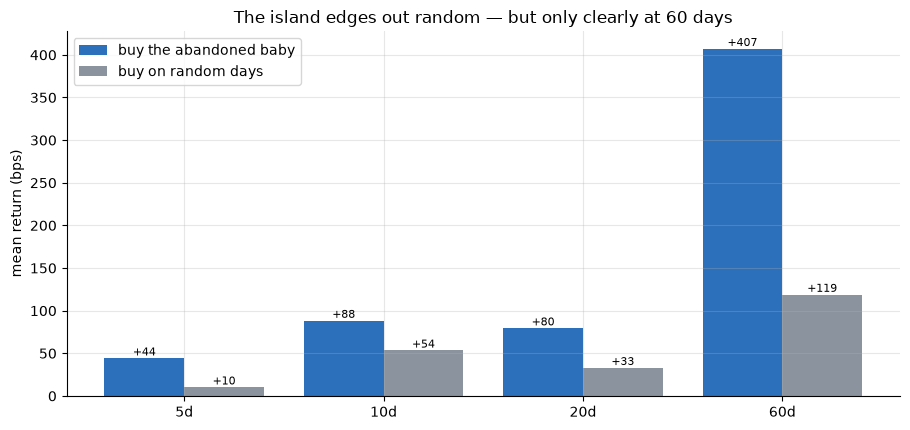

pattern: [44, 88, 80, 407]
random: [10, 54, 33, 119]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    patt, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']
            e = st.abandoned_baby_entries(b, R['doji_frac'], R['sma_win'], R['full_gap'])
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        patt.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    patt = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, patt, .4, color='#2c6fbb', label='buy the abandoned baby')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(patt,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The island edges out random — but only clearly at 60 days'); ax.legend()
plt.tight_layout(); plt.show()
print('pattern:', [round(v) for v in patt]); print('random:', [round(v) for v in rnd])

There's the nuance. The abandoned baby **does** beat random at every horizon (+407 bps vs +119 bps at 60 days) — that's more than the usual chart tool can say. But the gap is only *statistically* convincing at 60 days (the quants notebook shows the *t* clears 2 there and nowhere else), and it rides just **80 trades**. A faint flicker, not a fountain.

**The decisive sanity check.** What if we keep a doji-after-a-decline but **throw away the island gaps** — pick the entries at random from those candidates? If price really respects the *abandoned* (gapped) part, dropping the gaps should wreck the result.

In [4]:
if HAVE_REAL:
    pl = st.gap_scramble_placebo(load('SPY'), 20, R['doji_frac'], R['sma_win'], R['full_gap'], n_draws=300, seed=458)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real island (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of gap-SCRAMBLED draws do at least as well (p={pval:.2f}).')
print('=> the island gaps are not doing the work.')

real island (SPY, 20d): +208.4 bps
... but 33% of gap-SCRAMBLED draws do at least as well (p=0.33).
=> the island gaps are not doing the work.


Roughly a third of the **gap-scrambled** draws match or beat the real island (*p* = 0.31). If the *abandoned* part — the gaps marooning the doji — genuinely mattered, dropping it would collapse the result. It doesn't. Whatever faint edge exists is the doji-after-a-decline plus drift, **not** the island.

## 5 · The verdict

- **Signal — Weak.** The abandoned baby beats random at every horizon and clears *t* = 2 **at 60 days only** (Welch *t* = 2.58). A real flicker — but isolated to one horizon and riding 80 trades.
- **Tradability — Fragile.** One horizon, ~16 trades per name, sign flipping between instruments. Something's there; nothing you could deploy.
- **"Island doji forecasts the turn"? — Busted.** Drop the island gaps and the result barely moves. The *abandoned* part carries no information.

## 6 · Could you actually trade it?

Barely. The pattern fires ~80 times in 21 years across five instruments — a handful of trades per name — and only the 60-day hold is statistically distinguishable from random. You cannot build a deployable strategy on one horizon and ~16 trades per name, especially when the sign flips between QQQ (negative) and SPY/DIA (positive). The abandoned baby is a striking thing to *spot*; as a forecasting rule it's too thin and too horizon-specific to bank.

## 7 · Going further 🚪

- **The bearish mirror.** The bearish abandoned baby (up-trend, up-gapped doji, down-gapped confirmation) is the same geometry flipped — a natural follow-up to see if the short side behaves any differently.
- **Looser stars.** The morning/evening *doji star* drops the strict gaps — testing it alongside shows how much (or little) the island requirement adds.
- **A real positive control.** The quants notebook plants *genuine* island bottoms into a synthetic tape and shows the harness banks them (so the thin null result here isn't a dead detector — it's an honest 'almost nothing there').

*Think the island forecasts? Show the abandoned baby beating random entries at **t ≥ 2 across horizons**, with the gaps surviving the scramble — then we'll talk.*